In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [2]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

In [3]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month,Year
count,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000,20540.000000
mean,2020.131451,180.121227,23.742891,29.177993,19.266763,9.911230,2.740000,65.595643,2.969704,4.240090,91.747295,12.819402,6.423564,2020.131451
std,3.248591,106.284416,5.357470,5.125534,6.507759,5.516419,6.096451,21.857398,1.171500,1.402613,9.659611,5.008700,3.476707,3.248591
min,2015.000000,1.000000,10.030000,15.650000,1.170000,0.940000,0.000000,4.690000,0.460000,0.790000,76.360000,1.160000,1.000000,2015.000000
25%,2017.000000,86.000000,19.480000,26.700000,13.530000,4.380000,0.010000,56.207500,2.070000,3.130000,83.630000,9.530000,3.000000,2017.000000
50%,2020.000000,179.000000,25.210000,28.720000,21.960000,10.190000,0.390000,72.610000,2.820000,4.180000,96.310000,12.490000,6.000000,2020.000000
75%,2023.000000,272.000000,27.540000,30.710000,25.240000,14.810000,2.720000,82.530000,3.800000,5.240000,100.720000,17.640000,9.000000,2023.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,23.240000,166.100000,93.790000,8.400000,11.740000,101.510000,21.740000,12.000000,2026.000000


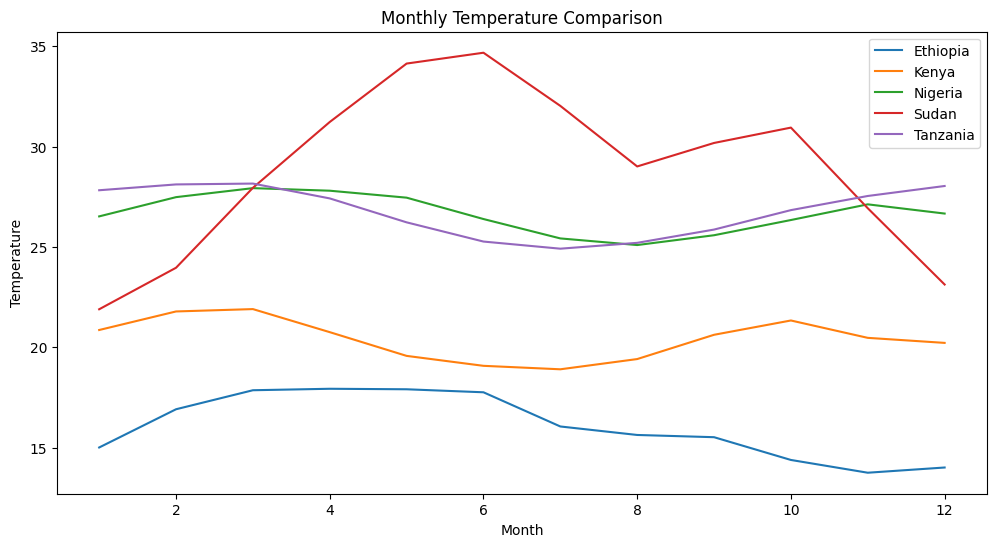

In [4]:
monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Month"], data["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

In [5]:
df.groupby("Country")["T2M"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


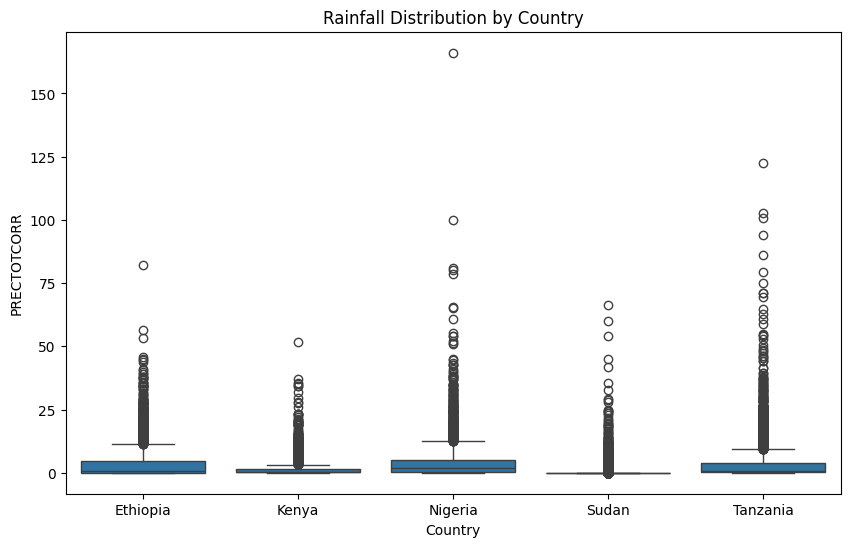

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Rainfall Distribution by Country")
plt.show()

In [7]:
df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


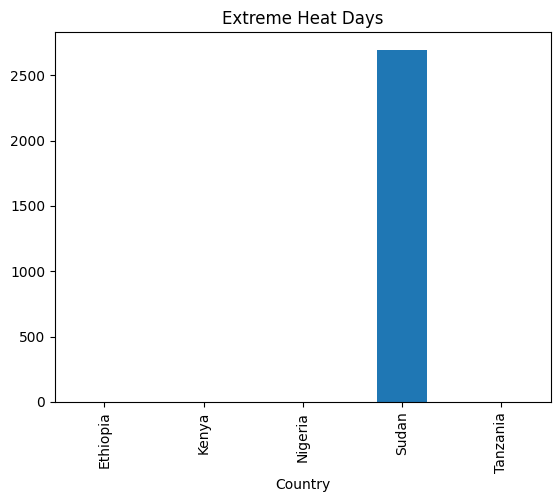

In [8]:
df["Extreme_Heat"] = df["T2M_MAX"] > 35

heat_counts = df.groupby("Country")["Extreme_Heat"].sum()

heat_counts.plot(kind="bar", title="Extreme Heat Days")
plt.show()

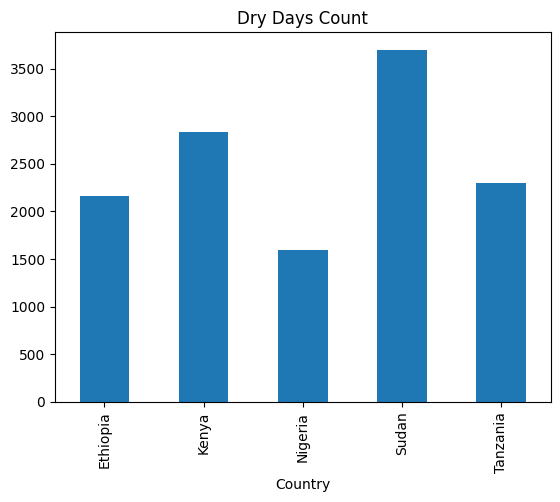

In [9]:
df["Dry_Day"] = df["PRECTOTCORR"] < 1

dry_counts = df.groupby("Country")["Dry_Day"].sum()

dry_counts.plot(kind="bar", title="Dry Days Count")
plt.show()

In [10]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


In [11]:
ranking = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std",
    "Extreme_Heat": "sum",
    "Dry_Day": "sum"
}).reset_index()

ranking.columns = [
    "Country",
    "Avg Temperature",
    "Rainfall Variability",
    "Extreme Heat Days",
    "Dry Days"
]

ranking["Vulnerability Score"] = (
    ranking["Avg Temperature"] +
    ranking["Rainfall Variability"] +
    ranking["Extreme Heat Days"] +
    ranking["Dry Days"]
)

ranking = ranking.sort_values(by="Vulnerability Score", ascending=False)
ranking["Rank"] = range(1, len(ranking)+1)

ranking

,Country,Avg Temperature,Rainfall Variability,Extreme Heat Days,Dry Days,Vulnerability Score,Rank
3,Sudan,28.759007,3.057672,2694,3696,6421.816679,1
1,Kenya,20.427600,3.180228,0,2831,2854.607828,2
4,Tanzania,26.802422,8.003947,0,2303,2337.806369,3
0,Ethiopia,16.068500,6.289061,0,2161,2183.357562,4
2,Nigeria,26.656928,7.266742,0,1595,1628.923670,5
